In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from google.cloud import storage
import io
from scipy.stats import gaussian_kde

In [2]:
df = pd.read_csv('../processed.csv')
print(df.columns)
df.shape

Index(['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0',
       'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views',
       'hours', 'engagement', 'description_json', 'duration_seconds'],
      dtype='str')


(12105, 16)

### Extract json

In [3]:
# json schema
# {
# "play_by_play": "",
# "content_theme": [""],
# "format_access": [""],
# "people": [""],
# "brands": [""],
# "event": [""],
# "tone": [""],
# "context": [""],
# "overall_team": [""],
# "audio_format": [""]
# }

In [4]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]


def _parse_json(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None
    try:
        return json.loads(text)
    except Exception:
        return None


json_dicts = df["description_json"].map(_parse_json)
df["description"] = json_dicts.map(
    lambda d: ((d or {}).get("play_by_play") or "").strip() or pd.NA
).astype("string")

# keep parsed dicts in scope for the encoding cell
json_by_idx = {idx: d for idx, d in zip(df.index, json_dicts) if d is not None}
print(f"parsed: {len(json_by_idx)} / {len(df)}")


parsed: 12105 / 12105


In [5]:
#df = df[df['description'].notna()] # this only deletes but does not reset the index
df = df.loc[df['description'].notna()].reset_index(drop=True)

### Building target categories

In [6]:
# categorical target - option 1: VB

nb_bins = 2

labels = ['L','H'] #['VL','L', 'M','H','VH']

df['views_level'] = pd.qcut(
    df['views'],
    q=nb_bins,
    labels=labels
)

df['engagement_level'] = pd.qcut(
    df['engagement'],
    q=nb_bins,
    labels=labels
)

df['category'] = (
    df['views_level'].astype('string')
    + 'V / '
    + df['engagement_level'].astype('string')
    + 'E'
)


In [7]:
# categorical target - option 2: RS

views_bin = (
    df["views"] >= df["views"].median()
).astype(int)

engagement_bin = (
    df["engagement"] >= df["engagement"].median()
).astype(int)

# Combine them into class numbers 0–3
class_id = views_bin * 2 + engagement_bin

# One-hot encode, always producing four columns
y = (
    pd.get_dummies(class_id)
    .reindex(columns=range(4), fill_value=False)
    .astype(int)
    .to_numpy()
)

# Readable labels
y_label = (
    "views_" + views_bin.astype(str)
    + "_engagement_" + engagement_bin.astype(str)
)

In [8]:
#same result if using a strict > instead of >=
y_label.value_counts(), df['category'].value_counts()

(views_1_engagement_1    5482
 views_0_engagement_0    5480
 views_0_engagement_1     571
 views_1_engagement_0     569
 Name: count, dtype: int64,
 category
 LV / LE    5482
 HV / HE    5480
 HV / LE     571
 LV / HE     569
 Name: count, dtype: int64[pyarrow])

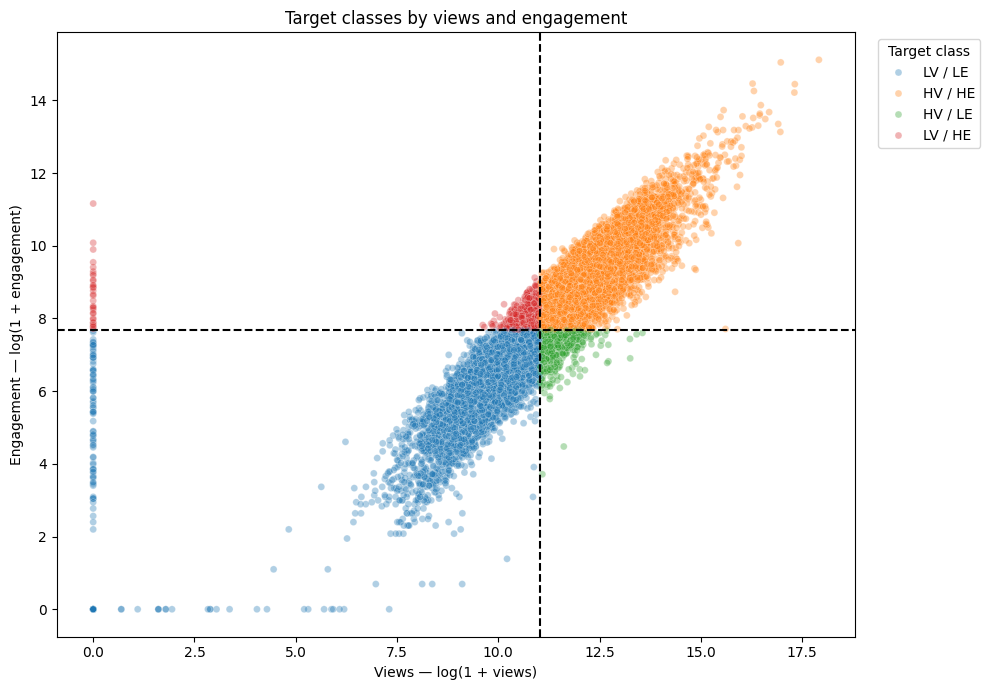

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.copy()

# Log transforms make highly skewed social metrics easier to see
plot_df['log_views'] = np.log1p(plot_df['views'])
plot_df['log_engagement'] = np.log1p(plot_df['engagement'])

views_cutoff = np.log1p(df['views'].median())
engagement_cutoff = np.log1p(df['engagement'].median())

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df,
    x='log_views',
    y='log_engagement',
    hue='category',
    alpha=0.35,
    s=25,
)

plt.axvline(views_cutoff, color='black', linestyle='--')
plt.axhline(engagement_cutoff, color='black', linestyle='--')

plt.xlabel('Views — log(1 + views)')
plt.ylabel('Engagement — log(1 + engagement)')
plt.title('Target classes by views and engagement')
plt.legend(title='Target class', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(
    'target_classes_scatter.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

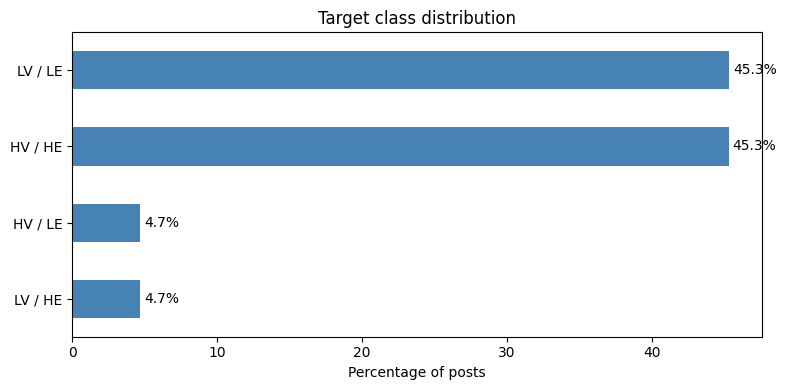

In [10]:
class_distribution = (
    df['category']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

ax = class_distribution.plot.barh(figsize=(8, 4), color='steelblue')

ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=3,
)

ax.set_xlabel('Percentage of posts')
ax.set_ylabel('')
ax.set_title('Target class distribution')
plt.tight_layout()

plt.savefig(
    'target_class_distribution.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

### Cleaning features

In [11]:
from collections import Counter

import regex

POST_TITLE_COLUMN = "content"
HASHTAG_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_])#([\p{L}\p{N}_]+)")
MENTION_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_@])@([\p{L}\p{N}_][\p{L}\p{N}_.]*)")
EMOJI_PATTERN = regex.compile(
    r"(?:\p{Regional_Indicator}{2}|[#*0-9]\uFE0F?\u20E3|"
    r"\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?"
    r"(?:\u200D\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?)*)"
)

# flagging hashtags, emojis, mentions
def add_content_flags(frame, column='content'):
    frame = frame.copy()

    text = frame[column].fillna("").astype(str)

    frame["has_hashtag"] = text.map(
        lambda value: int(bool(HASHTAG_PATTERN.findall(value)))
    ).astype("int8")

    frame["has_mention"] = text.map(
        lambda value: int(bool(MENTION_PATTERN.findall(value)))
    ).astype("int8")

    frame["has_emoji"] = text.map(
        lambda value: int(bool(EMOJI_PATTERN.findall(value)))
    ).astype("int8")

    return frame

df = add_content_flags(df)

# counting hashtags, emojis, mentions
def add_content_counts(frame, column="content"):
    frame = frame.copy()
    text = frame[column].fillna("").astype(str)

    frame["hashtag_count"] = text.map(
        lambda value: sum(1 for _ in HASHTAG_PATTERN.finditer(value))
    ).astype("int32")

    frame["mention_count"] = text.map(
        lambda value: sum(1 for _ in MENTION_PATTERN.finditer(value))
    ).astype("int32")

    frame["emoji_count"] = text.map(
        lambda value: sum(1 for _ in EMOJI_PATTERN.finditer(value))
    ).astype("int32")

    return frame

df = add_content_counts(df)

In [12]:
# additional numerical columns
df['duration_seconds'] = df['duration_seconds'].round().astype(int)
df['avg_views_platform_page_year'] = df.groupby(['platform', 'page', 'year'])['views'].transform('mean')
df['avg_engagement_platform_page_year'] = df.groupby(['platform', 'page', 'year'])['engagement'].transform('mean')

In [13]:
df['page_platform'] = df['page'] + '__' + df['platform']

In [14]:
df.shape

(12102, 29)

In [14]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plot_df = (
#     df[
#         [
#             'platform',
#             'page',
#             'year',
#             'avg_views_platform_page_year',
#             'avg_engagement_platform_page_year'
#         ]
#     ]
#     .drop_duplicates(['platform', 'page', 'year'])
#     .sort_values('year')
# )

In [15]:
# fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# sns.lineplot(
#     data=plot_df,
#     x='year',
#     y='avg_views_platform_page_year',
#     hue='platform',
#     style='page',
#     markers=True,
#     ax=axes[0]
# )
# axes[0].set(title='Average Views by Platform and Page', ylabel='Average views')

# sns.lineplot(
#     data=plot_df,
#     x='year',
#     y='avg_engagement_platform_page_year',
#     hue='platform',
#     style='page',
#     markers=True,
#     ax=axes[1]
# )
# axes[1].set(
#     title='Average Engagement by Platform and Page',
#     xlabel='Year',
#     ylabel='Average engagement'
# )

# plt.tight_layout()
# plt.show()

In [15]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate the OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Fit encoder
encoded_array = ohe.fit_transform(df[['platform','page', 'page_platform']])

# Convert back to a DataFrame with clear column names
encoded_cols = ohe.get_feature_names_out(['platform','page', 'page_platform'])
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, dtype=int)

df = df.reset_index(drop=True)
df_encoded = df_encoded.reset_index(drop=True)

df_final = pd.concat([df, df_encoded], axis=1)
df_final.shape

(12102, 57)

In [16]:
# Combine back with the numerical features
print(df.index.equals(df_encoded.index))
df = pd.concat([df, df_encoded], axis=1)

True


In [17]:
# df.columns.to_list()
df.groupby(['page_platform']).size().sort_values()

page_platform
ABXV__FB             123
Black Ferns__YT      146
NZ Sevens__TT        162
NZR__TT              170
SRP__FB              224
ABXV__IG             224
SRP__IG              250
NZ Sevens__FB        306
NZR__FB              324
Black Ferns__TT      381
NZR__IG              393
NZ Sevens__IG        421
Bunnings NPC__FB     658
Black Ferns__FB      691
Black Ferns__IG      739
Bunnings NPC__IG     833
All Blacks__TT      1084
All Blacks__YT      1386
All Blacks__FB      1783
All Blacks__IG      1804
dtype: int64

In [18]:
#['campaign', 'year', 'page', 'platform', 'media_type', 
#'category_l0', 'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 
#'views', 'hours', 'engagement', 
#'description_json', 
#'duration_seconds', 
#'views_level', 'engagement_level', 'category', 
#'has_hashtag', 'has_mention', 'has_emoji', 'hashtag_count', 'mention_count', 'emoji_count', 
#'avg_views_platform_page_year', 'avg_engagement_platform_page_year',
# 'platform_IG', 'platform_TT', 'platform_YT', 
# 'page_ABXV', 'page_All Blacks', 'page_Black Ferns', 'page_Bunnings NPC', 'page_NZ Sevens', 'page_NZR', 'page_SRP']

KEEP_COLUMNS = ['duration_seconds', 
                #'platform_IG', 'platform_TT', 'platform_YT', #'platform_FB',
                #'page_ABXV', 
                #'page_All Blacks', 'page_Black Ferns', 'page_Bunnings NPC', 'page_NZ Sevens', 'page_NZR', 'page_SRP',
                'page_platform_ABXV__IG', 'page_platform_All Blacks__FB','page_platform_All Blacks__IG','page_platform_All Blacks__TT',
                'page_platform_All Blacks__YT', 'page_platform_Black Ferns__FB', 'page_platform_Black Ferns__IG', 'page_platform_Black Ferns__TT',
                'page_platform_Black Ferns__YT', 'page_platform_Bunnings NPC__FB','page_platform_Bunnings NPC__IG', 'page_platform_NZ Sevens__FB',
                'page_platform_NZ Sevens__IG','page_platform_NZ Sevens__TT','page_platform_NZR__FB','page_platform_NZR__IG',
                'page_platform_NZR__TT','page_platform_SRP__FB','page_platform_SRP__IG',
                'hashtag_count', 'mention_count', 'emoji_count']

y = df['category']
X = df[KEEP_COLUMNS]

In [19]:
print(X.shape)
print(y.shape)
print(y_label.shape)

(12102, 23)
(12102,)
(12102,)


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numerical_cols = [
    'duration_seconds',
    'hashtag_count',
    'mention_count',
    'emoji_count'
]

binary_cols = [
    col for col in X.columns
    if col not in numerical_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_cols),
        ('binary', 'passthrough', binary_cols)
    ]
)

# 1. Fit the preprocessor to the data and transform it
X_processed_array = preprocessor.fit_transform(X)

# 2. Get the updated column names (StandardScaler keeps names, passthrough keeps names)
# Note: get_feature_names_out() requires scikit-learn 1.0+
column_names = preprocessor.get_feature_names_out()

# 3. Convert the resulting NumPy array back into a DataFrame
X_processed = pd.DataFrame(X_processed_array, columns=column_names, index=X.index)


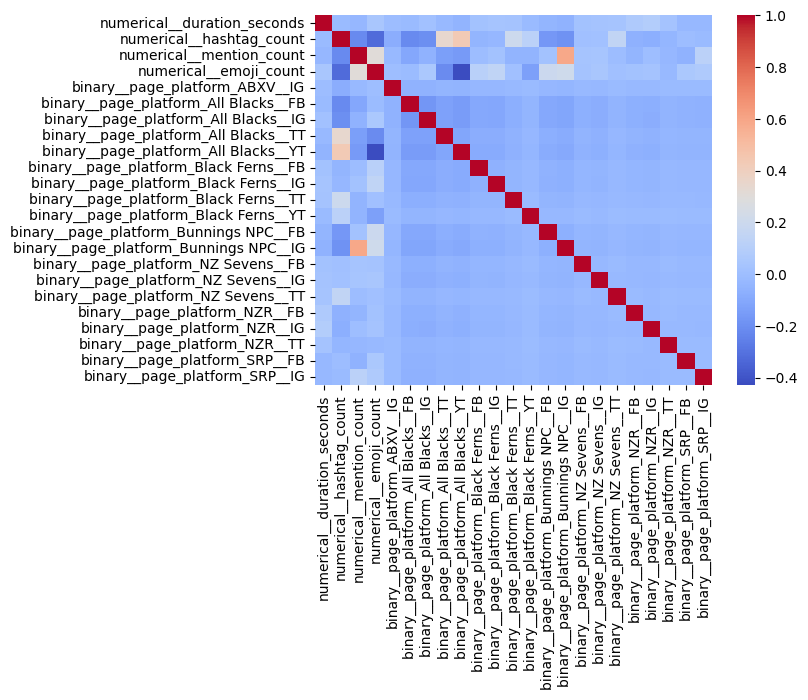

In [21]:
sns.heatmap(pd.DataFrame(X_processed).corr(), cmap='coolwarm');

In [22]:
from sklearn.decomposition import PCA

X_clean = X_processed.dropna()

pca = PCA().fit(X_clean)

pca.explained_variance_ratio_

array([3.29908260e-01, 2.06701172e-01, 1.64390834e-01, 1.33506723e-01,
       3.01339803e-02, 2.07727460e-02, 1.98947628e-02, 1.23107844e-02,
       1.17450671e-02, 1.02988573e-02, 9.21250294e-03, 7.70545999e-03,
       6.79926996e-03, 5.92889797e-03, 5.47308028e-03, 5.22470050e-03,
       4.39947581e-03, 3.84154327e-03, 3.73358188e-03, 2.96206949e-03,
       2.63096752e-03, 2.31961334e-03, 1.05649678e-04])

In [25]:
# Access all PCs 
W = pca.components_

# Print PCs as COLUMNS
W = pd.DataFrame(W.T,
                 index=X_clean.columns,
                 columns=[f'PC{i}' for i in range(1, len(X_clean.columns) + 1)])
# W


In [26]:
X_proj = pca.transform(X_clean)
X_proj = pd.DataFrame(X_proj, columns=[f'PC{i}' for i in range(1, len(X_clean.columns)+1)])
#X_proj

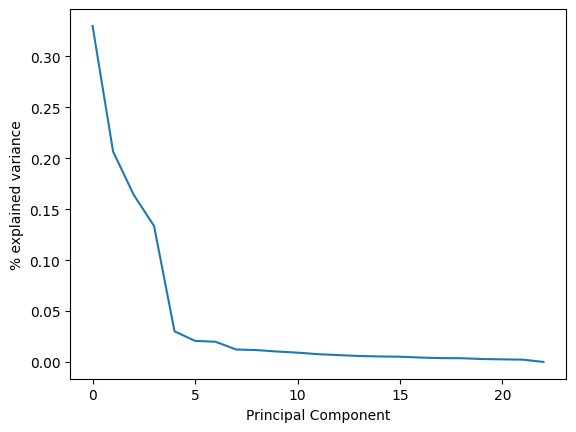

In [27]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Principal Component'); plt.ylabel('% explained variance');

In [35]:
# Fit a PCA with only 4 components
n = 4

pca4 = PCA(n_components=n).fit(X_clean)

# Project your data into 3 dimensions
X_proj4 = pd.DataFrame(pca4.fit_transform(X), columns=['PC1', 'PC2', 'PC3', 'PC4'])

# We have "compressed" our dataset in 3D
X_proj4

W4 = pca4.components_
W4.shape

W4 = pd.DataFrame(W4.T,
                 index=X_clean.columns,
                  columns=[f'PC{i}' for i in range(1, 5)])

W4
# W


,PC1,PC2,PC3,PC4
numerical__duration_seconds,0.999996,0.001598,-0.000748,0.001703
numerical__hashtag_count,-0.000023,-0.004659,-0.006434,-0.003763
numerical__mention_count,-0.000220,-0.034209,-0.061440,-0.072787
numerical__emoji_count,0.000196,-0.032476,-0.024322,-0.064492
binary__page_platform_ABXV__IG,-0.000281,0.045786,-0.023676,-0.004071
binary__page_platform_All Blacks__FB,-0.000622,0.066304,-0.087356,0.062793
binary__page_platform_All Blacks__IG,0.000215,-0.005453,0.020579,-0.024650
binary__page_platform_All Blacks__TT,0.000293,-0.004902,0.032571,-0.022475
binary__page_platform_All Blacks__YT,0.000166,0.015342,0.016320,-0.012555
binary__page_platform_Black Ferns__FB,-0.000075,0.006222,-0.009141,0.004784


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print("accuracy 4 PCs")
print(cross_val_score(LogisticRegression(max_iter=3000), X_proj4, y, cv=5).mean())

print("\naccuracy all initial features")
print(cross_val_score(LogisticRegression(max_iter=3000), X_clean, y, cv=5).mean())

accuracy 4 PCs
0.4664609255788708

accuracy all initial features
0.4810781351876316


In [58]:
X_clean.shape, y_label.shape, y.shape

((12102, 23), (12102,), (12102,))

In [61]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Logistic regression
pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=3000))
])

pipeline_1.fit(X, y)#(X_train, y_train)

#y_pred_1 = pipeline_1.predict(X_test)

print(classification_report(y_test, y_pred_1, zero_division=0))
print(f"(Accuracy): {accuracy_score(y_test, y_pred_1) * 100:.2f}%\n")

NameError: name 'classification_report' is not defined

In [39]:
fitted_model = pipeline_1.named_steps['model']

feature_names = (
    pipeline_1.named_steps['preprocessor']
    .get_feature_names_out()
)

coefficients = pd.DataFrame(
    fitted_model.coef_,
    index=fitted_model.classes_,
    columns=feature_names
)

coefficients.T

category = fitted_model.classes_[0]

# coefficients.loc[category].sort_values(
#     key=abs,
#     ascending=False
# )

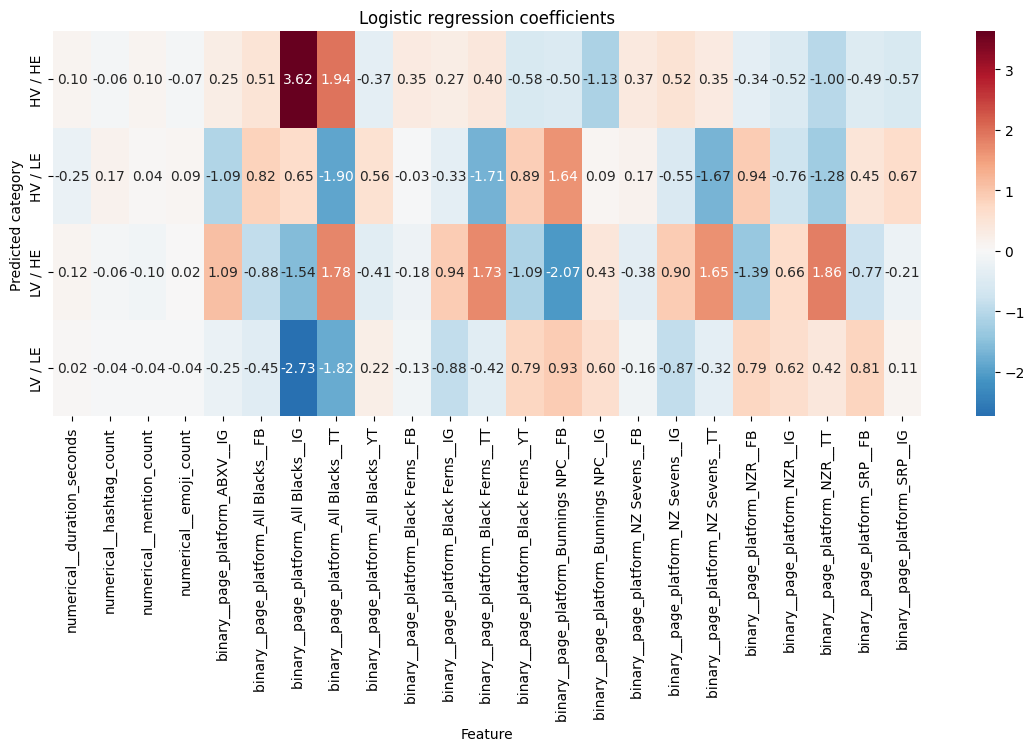

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

sns.heatmap(
    coefficients,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu_r"
)

plt.xlabel("Feature")
plt.ylabel("Predicted category")
plt.title("Logistic regression coefficients")
plt.savefig(
    'logit_coeff.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

In [65]:
# Random Forest Classif

pipeline_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline_2.fit(X_train, y_train)

y_pred_2 = pipeline_2.predict(X_test)

print(classification_report(y_test, y_pred_2, zero_division=0))
print(f"(Accuracy): {accuracy_score(y_test, y_pred_2) * 100:.2f}%\n")

                 precision    recall  f1-score   support

H_Views / H_Eng       0.72      0.75      0.73      1096
H_Views / L_Eng       0.05      0.03      0.04       114
L_Views / H_Eng       0.12      0.07      0.09       114
L_Views / L_Eng       0.71      0.74      0.72      1097

       accuracy                           0.68      2421
      macro avg       0.40      0.40      0.40      2421
   weighted avg       0.65      0.68      0.67      2421

(Accuracy): 68.07%



In [ ]:
X.columns.to_list()

### Additional encoding

In [ ]:
def _multi_hot_encode(frame, token_lists, prefix, column_name, min_frequency):
    if min_frequency < 1:
        raise ValueError("min_frequency must be at least 1")

    old_columns = [column for column in frame.columns if column.startswith(f"{prefix}_")]
    if old_columns:
        frame.drop(columns=old_columns, inplace=True)

    unique_tokens = token_lists.map(lambda tokens: list(dict.fromkeys(tokens)))
    frequencies = Counter(token for tokens in unique_tokens for token in tokens)
    vocabulary = sorted(token for token, count in frequencies.items() if count >= min_frequency)

    new_columns = {
        f"{prefix}_count": token_lists.map(len).astype("int16"),
        **{
            column_name(token): unique_tokens.map(
                lambda tokens, value=token: int(value in tokens)
            ).astype("int8")
            for token in vocabulary
        },
    }
    frame = pd.concat([frame, pd.DataFrame(new_columns, index=frame.index)], axis=1)
    return frame


def hashtag_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [tag.casefold() for tag in HASHTAG_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "hashtag", lambda tag: f"hashtag_{tag}", min_frequency
    )


def mention_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [mention.rstrip(".").casefold() for mention in MENTION_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "mention", lambda mention: f"mention_{mention}", min_frequency
    )


def emoji_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(EMOJI_PATTERN.findall)

    def emoji_column(value):
        codepoints = "_".join(f"{ord(char):x}" for char in value)
        return f"emoji_u{codepoints}"

    return _multi_hot_encode(frame, tokens, "emoji", emoji_column, min_frequency)


df_long = hashtag_encode(df)
df_long = mention_encode(df_long)
df_long = emoji_encode(df_long)

# NLP

### clustering descriptions

In [ ]:
# bash: pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['description'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

In [ ]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['description_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### clustering title

In [ ]:
# from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['content'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

In [ ]:

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

In [ ]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=12,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['title_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### drop stuff

In [ ]:
DROP = [
    'campaign',
    'media_type',
    "category_l0",
    "category_l1",
    "category_l2",
    'url',
    'content',
    'hours',
    'description',
    'cost_nzd',
    'year'
]

df = df.drop(columns=DROP)

In [ ]:
print(df.columns.tolist())

In [ ]:
IQR = df['views'].quantile(0.75) - df['views'].quantile(0.25)

lower_bound_views = df['views'].quantile(0.25) - 1.5 * IQR
upper_bound_views = df['views'].quantile(0.75) + 1.5 * IQR

In [ ]:
df['views'].hist(bins=100);

In [ ]:
print(df['views'].isna().sum())
df_plot = df[(df['views'] >= lower_bound_views) & (df['views'] <= upper_bound_views)]
df_plot['views'].hist(bins=50);
#df_plot['views'].plot(kind='box');

In [ ]:
IQR = df['engagement'].quantile(0.75) - df['engagement'].quantile(0.25)

lower_bound_eng = df['engagement'].quantile(0.25) - 1.5 * IQR
upper_bound_eng = df['engagement'].quantile(0.75) + 1.5 * IQR

In [ ]:
print(df['engagement'].isna().sum())
df = df[(df['engagement'] >= lower_bound_eng) & (df['engagement'] <= upper_bound_eng)]
df['engagement'].hist(bins=50)

## linreg views

In [ ]:
DROP_COLS = ['views', 'engagement']

X = df.drop(columns=DROP_COLS)

In [ ]:
labels = ['VL', 'L', 'M', 'H', 'VH']

df['views_level'] = pd.qcut(
    df['views'],
    q=5,
    labels=labels
)

df['engagement_level'] = pd.qcut(
    df['engagement'],
    q=5,
    labels=labels
)

df['category'] = (
    df['views_level'].astype('string')
    + '_Views / '
    + df['engagement_level'].astype('string')
    + '_Eng'
)

In [ ]:
df['views_level'].value_counts(), df['engagement_level'].value_counts(), df['category'].value_counts()

In [ ]:

df_1 = df[(df['views'] >= lower_bound_views) & (df['views'] <= upper_bound_views)]
df_small = df_1[(df_1['engagement'] >= lower_bound_eng) & (df_1['engagement'] <= upper_bound_eng)]

labels = ['L', 'M', 'H', ]


df['views_level'] = pd.qcut(
    df['views'],
    q=3,
    labels=labels
)

df['engagement_level'] = pd.qcut(
    df['engagement'],
    q=3,
    labels=labels
)

df_small['category_1'] = (
    df['views_level'].astype('string')
    + '_Views / '
    + df['engagement_level'].astype('string')
    + '_Eng'
)

In [ ]:
df['category_1'].value_counts()

In [ ]:
y = df['category']
df['category'].value_counts()
# df['H_Views / H_Eng'].count

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 7. Plot predicted vs actual with a y=x reference line.
y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Views + 1)')
plt.ylabel('Predicted log(NZR - Views + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [ ]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])


## linreg engagement

In [ ]:
X = df.drop(columns=DROP_COLS)

y = np.log1p(df['engagement'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Engagement + 1)')
plt.ylabel('Predicted log(NZR - Engagement + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [ ]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])

### NN

In [ ]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import RobustScaler

X = df.drop(columns=DROP_COLS)
# y = np.log1p(df[['engagement','views']])
y = np.log1p(df['engagement'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

# scaler = StandardScaler()
# scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

In [ ]:
from keras import Input
from keras import Sequential, layers

model = Sequential()
model.add(Input(shape=(X.shape[1],)))


model.add(layers.Dense(1080, activation='relu'))
model.add(layers.Dropout(rate=0.3)) 
model.add(layers.Dense(540, activation='relu'))
model.add(layers.Dropout(rate=0.3)) 
model.add(layers.Dense(270, activation='relu'))
model.add(layers.Dropout(rate=0.3)) 
model.add(layers.Dense(135, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(67, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(33, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dropout(rate=0.3))

# model.add(layers.Dense(2, activation='linear'))
model.add(layers.Dense(1, activation='linear'))


model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss' )
rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

history = model.fit(X_train, y_train, batch_size=32, epochs=1000, validation_split=0.2, callbacks=[es, rop])

In [ ]:
from plot_keras_history import plot_history

plot_history(history)

In [ ]:
results = model.evaluate(X_test, y_test)

print(f"Test Loss: {results[0]}")
print(f"Test MAE: {results[1]}")

In [ ]:
# Test Loss: 5.3443989753723145
# Test MAE: 1.5442880392074585

dummy_views = 10_000
error_range = np.exp(results[1])
low = dummy_views / error_range
high = dummy_views * error_range
print(error_range)
print(round(low,-3),'<--',dummy_views, '-->',round(high, -3))

baseline_mean = y_train.mean()
baseline_preds = abs(y_test - baseline_mean)
print('baseline mae', baseline_preds.mean())
print('model mae', results[1])